Parcial 3 - Astroestadística

Modelo de Regresión Lineal Bayesiana para Cefeidas

Relación Período-Luminosidad: $M = a + b*\log10(P) + \varepsilon$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

In [3]:
df = pd.read_csv('mw_cepheids.csv')
for col in ['Per', 'plx', 'Vmag']:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # texto -> NaN
df.dropna(subset=['Per', 'plx', 'Vmag'], inplace=True) # elimina NaN

In [4]:
print(df.head())

        _RAJ2000      _DEJ2000     Per    plx    Vmag   Imag
2    916.456.086   +26.3292228  11.302  311.0   9.735    NaN
3  1.052.492.503   -87.089.917   8.014  383.0  10.100  8.708
5  1.170.160.469  -255.777.844  13.596  254.0   9.898  8.716
6  1.442.144.433  -530.327.967   7.134  369.0  10.257  8.730
7  1.903.584.572  -597.941.783   3.837  758.0   8.228  7.346


In [5]:
plx_arcsec = df['plx'].values / 1000                        # paralaje [arcsec]
x  = np.log10(df['Per'].values)                             # log10(P_i) [adim]
y  = df['Vmag'].values + 5*np.log10(plx_arcsec) + 5         # M_i [mag]
n  = len(x)
sigma = 0.3                                                 # desv. est. conocida

# a) Gráfico de dispersión

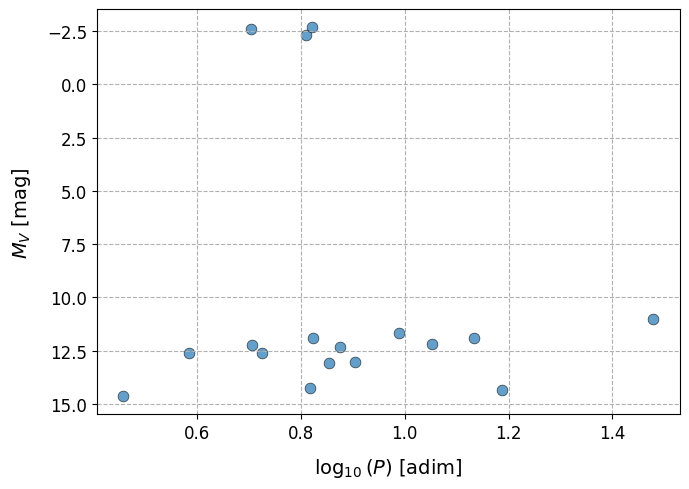

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(x, y, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)

plt.xlabel(r'$\log_{10}(P)$ [adim]', fontsize=14, labelpad=10)
plt.ylabel(r'$M_V$ [mag]', fontsize=14, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().invert_yaxis()
plt.grid(ls="--")

plt.tight_layout() 
plt.savefig('dispersion.png', dpi=300)


# d) Estimación MAP

In [7]:
sum_x  = x.sum();    sum_x2 = (x**2).sum()   # estadisticos suficientes
sum_y  = y.sum();    sum_xy = (x*y).sum()

M_mat = np.array([[n + sigma**2/100, sum_x ],
                   [sum_x,           sum_x2 + sigma**2/100]])  # matriz M
Z_vec = np.array([sum_y, sum_xy])                              # vector Z

a_map, b_map = np.linalg.solve(M_mat, Z_vec)   # resuelve M theta = Z

In [8]:
print(f"a_map: {a_map:.4f}, b_map: {b_map:.4f}")

a_map: 7.2506, b_map: 3.1462


# e) La posterior es una normal bivariada

In [9]:
A = n/sigma**2 + 1/100
B = sum_x/sigma**2
C = sum_x2/sigma**2 + 1/100

Prec  = np.array([[A, B], [B, C]])  # matriz de precision Sigma^{-1}
Sigma = np.linalg.inv(Prec)         # covarianza posterior

In [10]:
# 2. Imprimes directamente las matrices
print("Matriz de Precisión:\n", Prec)
print("\nMatriz de Covarianza Posterior:\n", Sigma)

Matriz de Precisión:
 [[188.8989 165.8626]
 [165.8626 155.9583]]

Matriz de Covarianza Posterior:
 [[ 0.08   -0.0851]
 [-0.0851  0.0969]]


# f) Muestras de la distribución posterior

In [11]:
np.random.seed(42)
theta_s = np.random.multivariate_normal([a_map, b_map], Sigma, size=10_000)
a_s, b_s = theta_s[:, 0], theta_s[:, 1]   # muestras marginales de a y b

# g) Intervalo de credibilidad del $95\%$ para $a$ y $b$

In [12]:
ci_a = np.percentile(a_s, [2.5, 97.5])   # IC 95% para a
ci_b = np.percentile(b_s, [2.5, 97.5])   # IC 95% para b

# h) Distribución posterior predictiva para $P = 12$ días.

In [13]:
x_new  = np.log10(12)                          # log10(P) para P = 12 dias
M_pred = a_s + b_s * x_new                    # distribucion predictiva posterior
mu_pred, ci_pred = M_pred.mean(), np.percentile(M_pred, [2.5, 97.5])

# i) Relación período--luminosidad con banda de credibilidad.

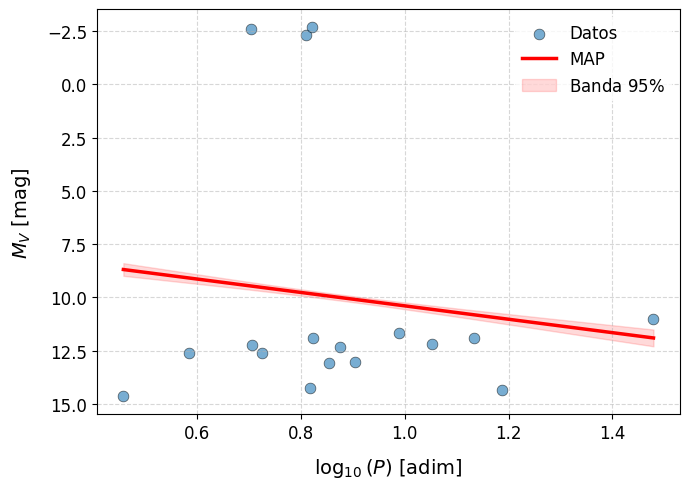

In [14]:
x_grid = np.linspace(x.min(), x.max(), 300)
M_grid = a_s[:, None] + b_s[:, None]*x_grid  # (10000, 300): curva por muestra
lo, hi = np.percentile(M_grid, [2.5, 97.5], axis=0)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=60, alpha=0.6, edgecolors='black', linewidths=0.5, label='Datos')
plt.plot(x_grid, a_map + b_map*x_grid, 'r-', lw=2.5, label='MAP')
plt.fill_between(x_grid, lo, hi, color='red', alpha=0.15, label=r'Banda $95\%$')
plt.xlabel(r'$\log_{10}(P)$ [adim]', fontsize=14, labelpad=10)
plt.ylabel(r'$M_V$ [mag]', fontsize=14, labelpad=10)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12, loc='best', frameon=True, facecolor='white', edgecolor='none')

plt.gca().invert_yaxis()
plt.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig('pl_band.png', dpi=300)

# j) Comparación con regresión por mínimos cuadrados (OLS).

In [15]:
X_mat = np.column_stack([np.ones(n), x])                    # diseno [1 | x]
a_ols, b_ols = np.linalg.lstsq(X_mat, y, rcond=None)[0]    # estimacion OLS

In [16]:
print(f"a_ols (Intercepto): {a_ols:.4f}")
print(f"b_ols (Pendiente):  {b_ols:.4f}")

a_ols (Intercepto): 7.2538
b_ols (Pendiente):  3.1431


# Parte B

## Inciso a)

In [17]:
B = 2000  
a_boot, b_boot = [], []
for _ in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    X_b = np.column_stack([np.ones(n), x[idx]])
    y_b = y[idx]
    theta_b = np.linalg.lstsq(X_b, y_b, rcond=None)[0]
    a_boot.append(theta_b[0]); b_boot.append(theta_b[1])

ci_a_boot = np.percentile(a_boot, [2.5, 97.5])
ci_b_boot = np.percentile(b_boot, [2.5, 97.5])
print(f"IC Bootstrap 95% a: {ci_a_boot}, b: {ci_b_boot}")

IC Bootstrap 95% a: [-7.455  14.5516], b: [-3.1659 17.4093]


## Inciso b)

In [20]:
from scipy import stats

# Residuos observados usando estimadores MAP
y_pred_map = a_map + b_map * x
res_obs = y - y_pred_map

# Residuos sinteticos (simulamos 10^4 conjuntos, tomamos uno representativo o aplanamos)
# Para la prueba K-S, aplanamos las simulaciones para tener una gran muestra de referencia
res_sim = np.random.normal(0, sigma, size=(10000, n)).flatten()

# Prueba de Kolmogorov-Smirnov de dos muestras
D_stat, p_value = stats.ks_2samp(res_obs, res_sim)
print(f"Estadistico K-S D = {D_stat:.4f}, p-valor = {p_value:.2e}")

Estadistico K-S D = 0.7646, p-valor = 6.71e-11


## Inciso c)

In [19]:
# 1. Estimadores MAP del modelo cuadratico
x2 = x**2
sum_x3 = (x**3).sum(); sum_x4 = (x**4).sum(); sum_x2y = (x2*y).sum()
M_quad = np.array([
    [n + sigma**2/100, sum_x,           sum_x2],
    [sum_x,            sum_x2 + sigma**2/100, sum_x3],
    [sum_x2,           sum_x3,          sum_x4 + sigma**2/100]
])
Z_quad = np.array([sum_y, sum_xy, sum_x2y])
a_q, b_q, c_q = np.linalg.solve(M_quad, Z_quad)

# 2. Comparacion de poder predictivo via Bootstrap (MSE)
mse_lin, mse_quad = [], []
for _ in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    x_b, y_b = x[idx], y[idx]
    
    # MSE Lineal
    X_b_lin = np.column_stack([np.ones(n), x_b])
    theta_lin = np.linalg.lstsq(X_b_lin, y_b, rcond=None)[0]
    mse_lin.append(np.mean((y_b - X_b_lin @ theta_lin)**2))
    
    # MSE Cuadratico
    X_b_quad = np.column_stack([np.ones(n), x_b, x_b**2])
    theta_quad = np.linalg.lstsq(X_b_quad, y_b, rcond=None)[0]
    mse_quad.append(np.mean((y_b - X_b_quad @ theta_quad)**2))

print(f"MSE Lineal (mediana bootstrap): {np.median(mse_lin):.4f}")
print(f"MSE Cuadratico (mediana bootstrap): {np.median(mse_quad):.4f}")

MSE Lineal (mediana bootstrap): 32.9269
MSE Cuadratico (mediana bootstrap): 30.2544
